# 01 - TOI Catalog EDA

Exploración del TOI Catalog descargado desde el NASA Exoplanet Archive.

**Objetivo:** confirmar conteos reales de CP/FP, analizar las 6 variables clave del pipeline, detectar NaNs críticos y generar `data/splits/tics_labeled.csv`.

Ejecutar desde la raíz del repositorio con el venv activo.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [2]:
ROOT = Path("..").resolve()
RAW = ROOT / "data/raw/toi_catalog.csv"
SPLITS = ROOT / "data/splits"
assert RAW.exists(), f"Catalogo no encontrado: {RAW}. Correr scripts/get_data.py primero."

df = pd.read_csv(RAW, low_memory=False)
print(f"Filas: {len(df):,}  |  Columnas: {df.shape[1]}")

Filas: 7,931  |  Columnas: 91


## 1. Distribución de disposiciones

In [3]:
counts = df["tfopwg_disp"].value_counts(dropna=False)
print(counts.to_string())

labeled = df[df["tfopwg_disp"].isin(["CP", "FP"])].copy()
print(f"\nEtiquetados (CP + FP): {len(labeled):,}")
print(f"Ratio CP:FP = 1:{len(labeled[labeled.tfopwg_disp == 'FP']) / len(labeled[labeled.tfopwg_disp == 'CP']):.2f}")

tfopwg_disp
PC     4788
FP     1242
CP      726
KP      591
APC     481
FA      100
NaN       3

Etiquetados (CP + FP): 1,968
Ratio CP:FP = 1:1.71


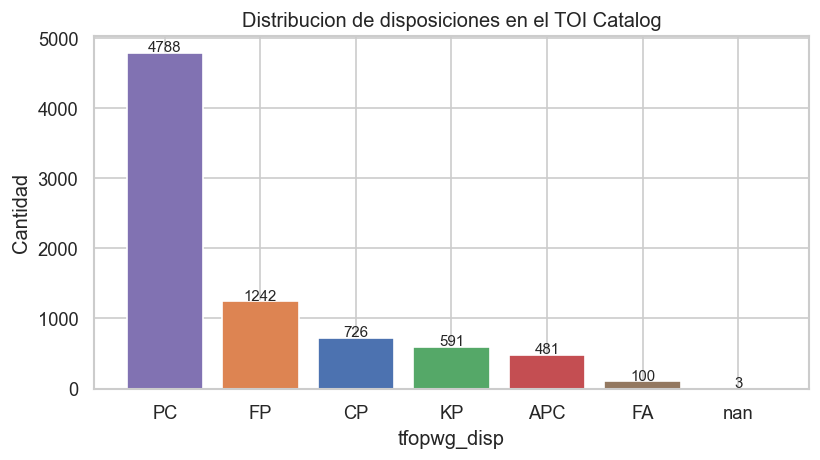

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = {"CP": "#4C72B0", "FP": "#DD8452", "PC": "#8172B2", "KP": "#55A868", "APC": "#C44E52", "FA": "#937860"}
bars = counts.index.map(lambda x: str(x))
ax.bar(bars, counts.values, color=[colors.get(str(k), "gray") for k in counts.index])
ax.set_xlabel("tfopwg_disp")
ax.set_ylabel("Cantidad")
ax.set_title("Distribucion de disposiciones en el TOI Catalog")
for i, v in enumerate(counts.values):
    ax.text(i, v + 20, str(v), ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## 2. Magnitud TESS (st_tmag) por clase

Estrellas más débiles (tmag alto) tienen curvas con menor SNR. Se analiza si hay un umbral razonable para filtrar.

In [5]:
print("NaN en st_tmag:")
print(labeled.groupby("tfopwg_disp")["st_tmag"].apply(lambda s: s.isna().sum()))
print()
print(labeled.groupby("tfopwg_disp")["st_tmag"].describe().round(2))

NaN en st_tmag:
tfopwg_disp
CP    0
FP    0
Name: st_tmag, dtype: int64

              count   mean   std   min    25%    50%    75%    max
tfopwg_disp                                                       
CP            726.0  10.50  1.74  5.11   9.27  10.49  11.56  16.34
FP           1242.0  11.06  1.62  5.53  10.00  10.67  12.36  18.33


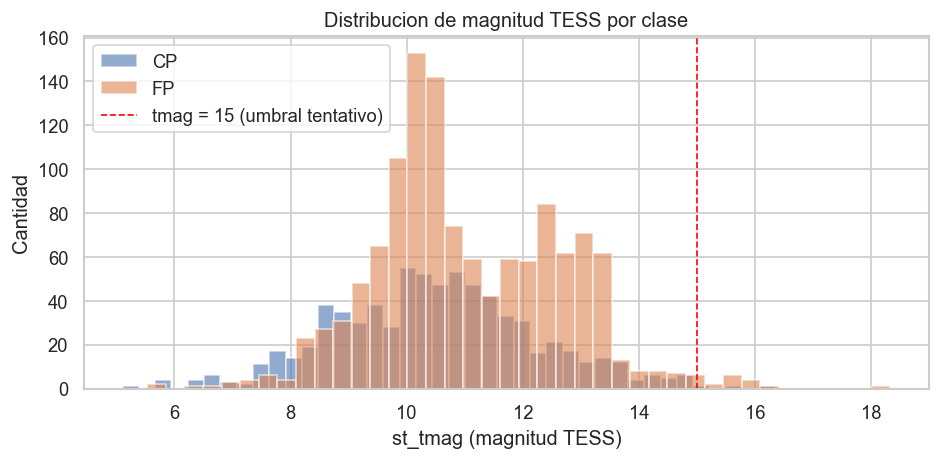

CP: 2/726 estrellas con tmag > 15 (0.3%)
FP: 16/1242 estrellas con tmag > 15 (1.3%)


In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
for disp, color in [("CP", "#4C72B0"), ("FP", "#DD8452")]:
    data = labeled[labeled.tfopwg_disp == disp]["st_tmag"].dropna()
    ax.hist(data, bins=40, alpha=0.6, label=disp, color=color)
ax.axvline(15, color="red", linestyle="--", linewidth=1, label="tmag = 15 (umbral tentativo)")
ax.set_xlabel("st_tmag (magnitud TESS)")
ax.set_ylabel("Cantidad")
ax.set_title("Distribucion de magnitud TESS por clase")
ax.legend()
plt.tight_layout()
plt.show()

for disp in ["CP", "FP"]:
    n_faint = (labeled[labeled.tfopwg_disp == disp]["st_tmag"] > 15).sum()
    n_total = len(labeled[labeled.tfopwg_disp == disp])
    print(f"{disp}: {n_faint}/{n_total} estrellas con tmag > 15 ({n_faint/n_total*100:.1f}%)")

## 3. Periodo orbital (pl_orbper)

Confirma que los tránsitos ocurren dentro de los ~27 dias de un sector. Períodos muy largos implican que puede no haber tránsito completo en una sola curva.

In [7]:
print("NaN en pl_orbper:")
print(labeled.groupby("tfopwg_disp")["pl_orbper"].apply(lambda s: s.isna().sum()))
print()
print(labeled.groupby("tfopwg_disp")["pl_orbper"].describe().round(2))

NaN en pl_orbper:
tfopwg_disp
CP     6
FP    11
Name: pl_orbper, dtype: int64

              count   mean    std   min   25%   50%    75%      max
tfopwg_disp                                                        
CP            720.0  16.18  63.16  0.22  3.27  5.70  12.20  1134.67
FP           1231.0   9.57  67.70  0.16  1.50  2.85   5.93  1825.05


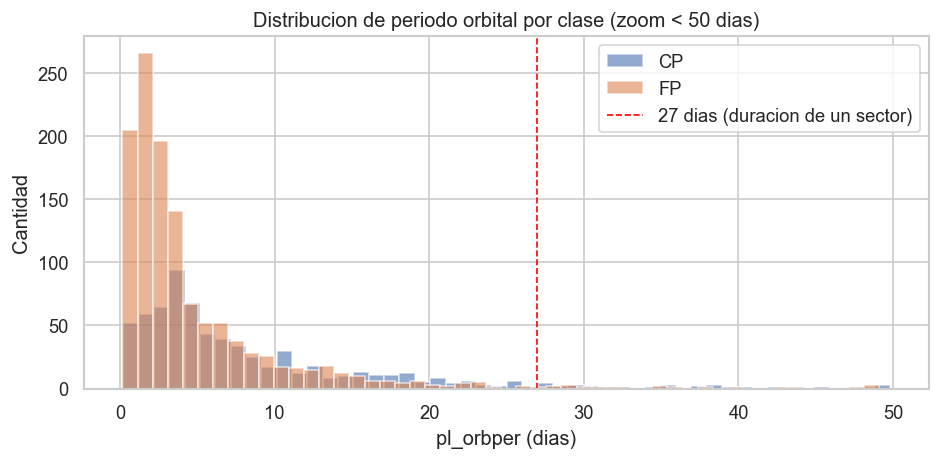

CP: 64/726 con periodo > 27 dias (8.8%)
FP: 33/1242 con periodo > 27 dias (2.7%)


In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
for disp, color in [("CP", "#4C72B0"), ("FP", "#DD8452")]:
    data = labeled[labeled.tfopwg_disp == disp]["pl_orbper"].dropna()
    data = data[data < 50]  # zoom en rango útil
    ax.hist(data, bins=50, alpha=0.6, label=disp, color=color)
ax.axvline(27, color="red", linestyle="--", linewidth=1, label="27 dias (duracion de un sector)")
ax.set_xlabel("pl_orbper (dias)")
ax.set_ylabel("Cantidad")
ax.set_title("Distribucion de periodo orbital por clase (zoom < 50 dias)")
ax.legend()
plt.tight_layout()
plt.show()

for disp in ["CP", "FP"]:
    n_long = (labeled[labeled.tfopwg_disp == disp]["pl_orbper"] > 27).sum()
    n_total = len(labeled[labeled.tfopwg_disp == disp])
    print(f"{disp}: {n_long}/{n_total} con periodo > 27 dias ({n_long/n_total*100:.1f}%)")

## 4. Profundidad del tránsito (pl_trandep)

Diferencia entre CP y FP puede ser informativa. Importante: **no se usa como feature del modelo** porque es derivada de la misma señal que el modelo analiza, lo que sería data leakage.

In [9]:
print("NaN en pl_trandep:")
print(labeled.groupby("tfopwg_disp")["pl_trandep"].apply(lambda s: s.isna().sum()))
print()
print(labeled.groupby("tfopwg_disp")["pl_trandep"].describe().round(1))

NaN en pl_trandep:
tfopwg_disp
CP    0
FP    0
Name: pl_trandep, dtype: int64

              count    mean      std    min     25%     50%     75%       max
tfopwg_disp                                                                  
CP            726.0  6932.3  23063.7   82.7   846.2  1964.6  6467.5  484643.7
FP           1242.0  8206.3  24781.5  104.3  1070.4  2870.0  7346.7  504062.4


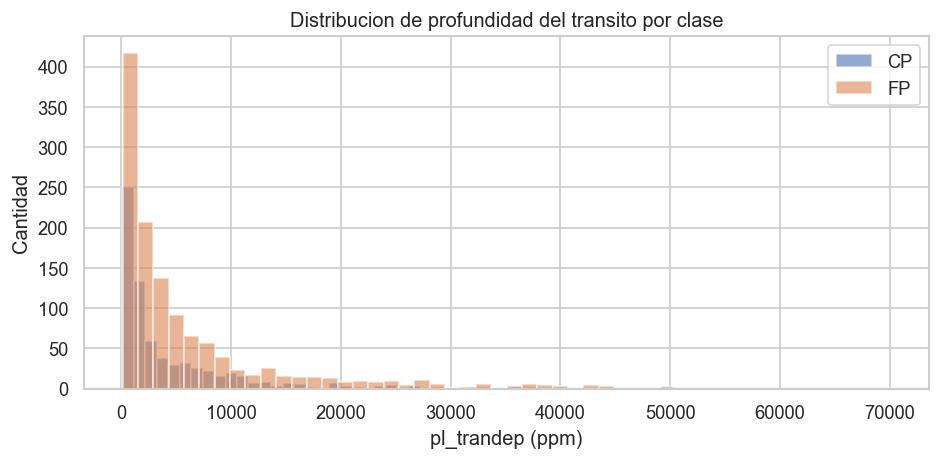

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
for disp, color in [("CP", "#4C72B0"), ("FP", "#DD8452")]:
    data = labeled[labeled.tfopwg_disp == disp]["pl_trandep"].dropna()
    data = data[data < data.quantile(0.99)]  # recortar outliers extremos
    ax.hist(data, bins=50, alpha=0.6, label=disp, color=color)
ax.set_xlabel("pl_trandep (ppm)")
ax.set_ylabel("Cantidad")
ax.set_title("Distribucion de profundidad del transito por clase")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Duracion del tránsito (pl_trandurh)

A cadencia de 2 minutos, cada hora de tránsito equivale a 30 puntos. Una duración de 1 hora = señal de 30 puntos en 18,000.

In [11]:
print("NaN en pl_trandurh:")
print(labeled.groupby("tfopwg_disp")["pl_trandurh"].apply(lambda s: s.isna().sum()))
print()
print(labeled.groupby("tfopwg_disp")["pl_trandurh"].describe().round(2))

print("\nPuntos que abarca el transito promedio (a 2 min/punto):")
for disp in ["CP", "FP"]:
    median_h = labeled[labeled.tfopwg_disp == disp]["pl_trandurh"].median()
    print(f"  {disp}: mediana {median_h:.2f} h = {median_h * 30:.0f} puntos")

NaN en pl_trandurh:
tfopwg_disp
CP    0
FP    0
Name: pl_trandurh, dtype: int64

              count  mean   std   min   25%   50%   75%    max
tfopwg_disp                                                   
CP            726.0  3.06  2.18  0.20  1.64  2.56  3.98  24.05
FP           1242.0  2.87  1.57  0.21  1.76  2.59  3.49  11.54

Puntos que abarca el transito promedio (a 2 min/punto):
  CP: mediana 2.56 h = 77 puntos
  FP: mediana 2.59 h = 78 puntos


## 6. Cobertura de sectores

Cuántos sectores por estrella determina cuántos `.fits` se descargan en Fase 2.

              count  mean  std  min  25%  50%  75%  max
tfopwg_disp                                            
CP            726.0   0.0  0.0  0.0  0.0  0.0  0.0  0.0
FP           1242.0   0.0  0.0  0.0  0.0  0.0  0.0  0.0


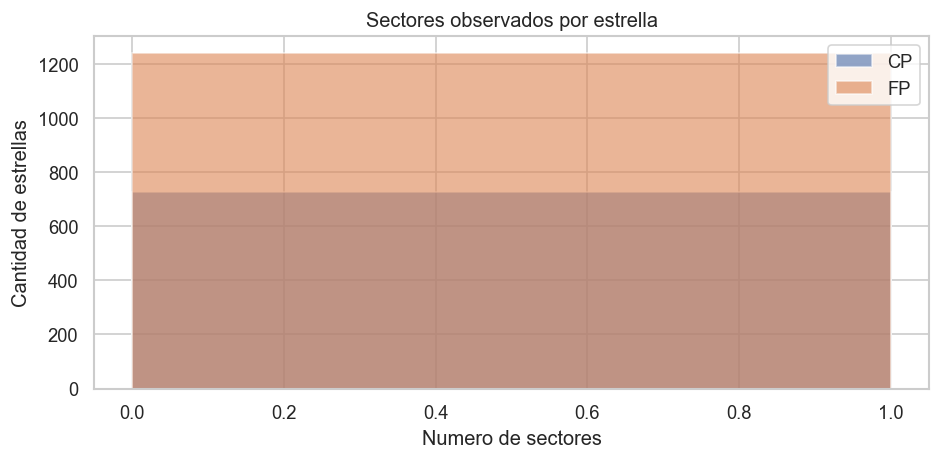

In [12]:
def count_sectors(s):
    if pd.isna(s):
        return 0
    return len(str(s).split(","))

labeled["n_sectors"] = labeled["sectors"].apply(count_sectors)

print(labeled.groupby("tfopwg_disp")["n_sectors"].describe().round(1))

fig, ax = plt.subplots(figsize=(8, 4))
for disp, color in [("CP", "#4C72B0"), ("FP", "#DD8452")]:
    data = labeled[labeled.tfopwg_disp == disp]["n_sectors"]
    ax.hist(data, bins=range(0, int(data.max()) + 2), alpha=0.6, label=disp, color=color)
ax.set_xlabel("Numero de sectores")
ax.set_ylabel("Cantidad de estrellas")
ax.set_title("Sectores observados por estrella")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Resumen de NaNs en variables clave

In [13]:
key_cols = ["st_tmag", "pl_orbper", "pl_trandep", "pl_trandurh", "sectors"]
nan_summary = labeled[key_cols].isna().sum().rename("NaNs")
nan_summary["NaN %"] = (labeled[key_cols].isna().mean() * 100).round(1)
print(nan_summary)

st_tmag                                                        0
pl_orbper                                                     17
pl_trandep                                                     0
pl_trandurh                                                    0
sectors                                                     1968
NaN %          st_tmag          0.0
pl_orbper        0.9
pl_t...
Name: NaNs, dtype: object


## 8. Generar tics_labeled.csv

Archivo versionado con solo los TIC IDs etiquetados (CP y FP). Este es el contrato con Fase 2.

In [14]:
out = SPLITS / "tics_labeled.csv"
SPLITS.mkdir(parents=True, exist_ok=True)

tics = labeled[["tid", "tfopwg_disp", "st_tmag", "pl_orbper", "n_sectors"]].copy()
tics["label"] = (tics["tfopwg_disp"] == "CP").astype(int)
tics = tics.sort_values("tid").reset_index(drop=True)
tics.to_csv(out, index=False)

print(f"Guardado: {out}")
print(f"Total: {len(tics):,}  |  CP (label=1): {tics.label.sum():,}  |  FP (label=0): {(1-tics.label).sum():,}")
tics.head()

Guardado: C:\Users\jfzum\Downloads\Proyecto-IA\mamba-exoplanet\data\splits\tics_labeled.csv


Total: 1,968  |  CP (label=1): 726  |  FP (label=0): 1,242


,tid,tfopwg_disp,st_tmag,pl_orbper,n_sectors,label
0,1003831,CP,10.6701,1.651146,0,1
1,1133072,FP,12.6250,0.846542,0,0
2,1167538,CP,10.0127,NaN,0,1
3,1449756,FP,10.8256,11.354309,0,0
4,1528696,CP,13.1686,0.882062,0,1
